 # testing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [2]:
example_data = pd.read_csv('../data/5/exp05H20140926_10h50.csv')

## HEADING ALIGNMENT

- Close to 1 ~ similar direction/aligment
- Close to 0 ~ uncoordinated
- Close to -1 ~ opposite direction/aligment

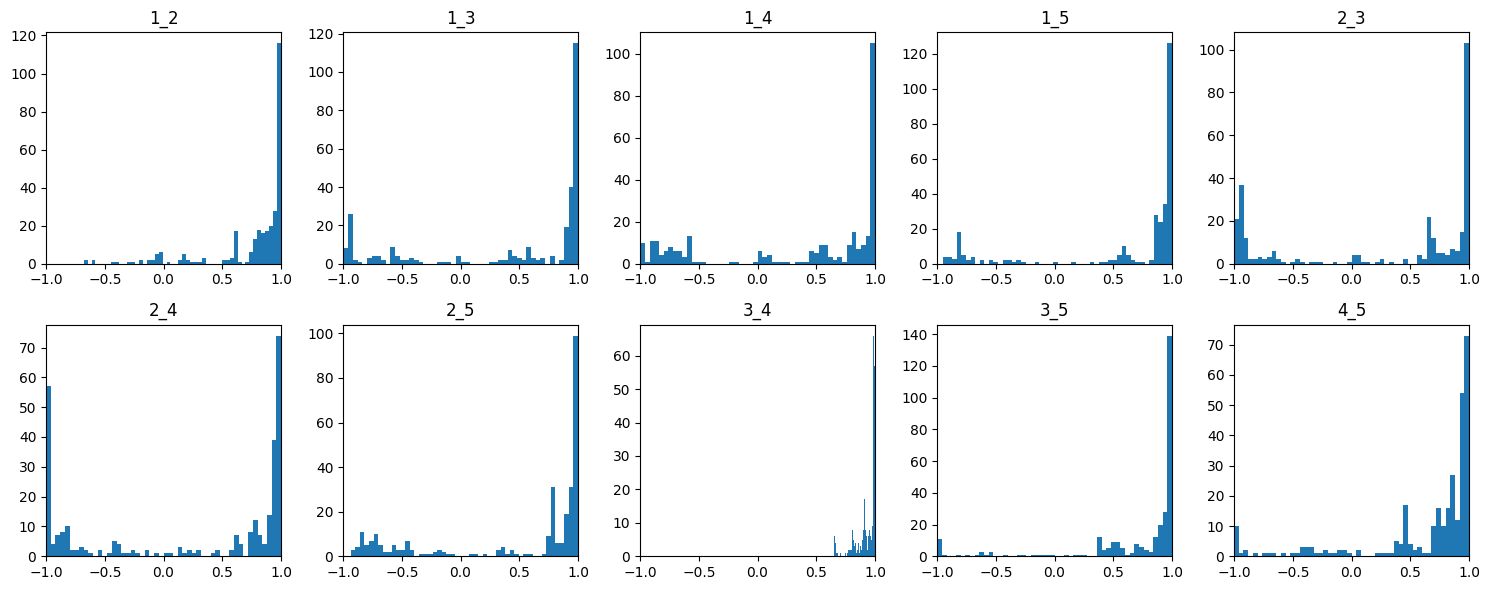

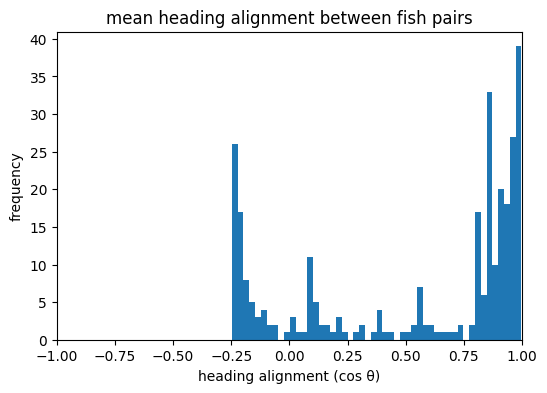

count    301.000000
mean       0.542652
std        0.473991
min       -0.247331
25%        0.089264
50%        0.837415
75%        0.936708
max        0.997395
dtype: float64


In [22]:
n = 5
alignment = pd.DataFrame(index=example_data.index)
for i in range(1, n + 1):
    for j in range(i + 1, n + 1):
        alignment[f'{i}_{j}'] = np.cos(example_data[f'H{i}'] - example_data[f'H{j}'])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i, col in enumerate(alignment.columns):
    axes[i].hist(alignment[col], bins=50)
    axes[i].set_title(col)
    axes[i].set_xlim(-1, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(alignment.mean(axis=1), bins=50)
plt.xlabel('heading alignment')
plt.ylabel('frequency')
plt.title('mean heading alignment between fish pairs')
plt.xlim(-1, 1)
plt.show()
print(alignment.mean(axis=1).describe())



## Speed difference

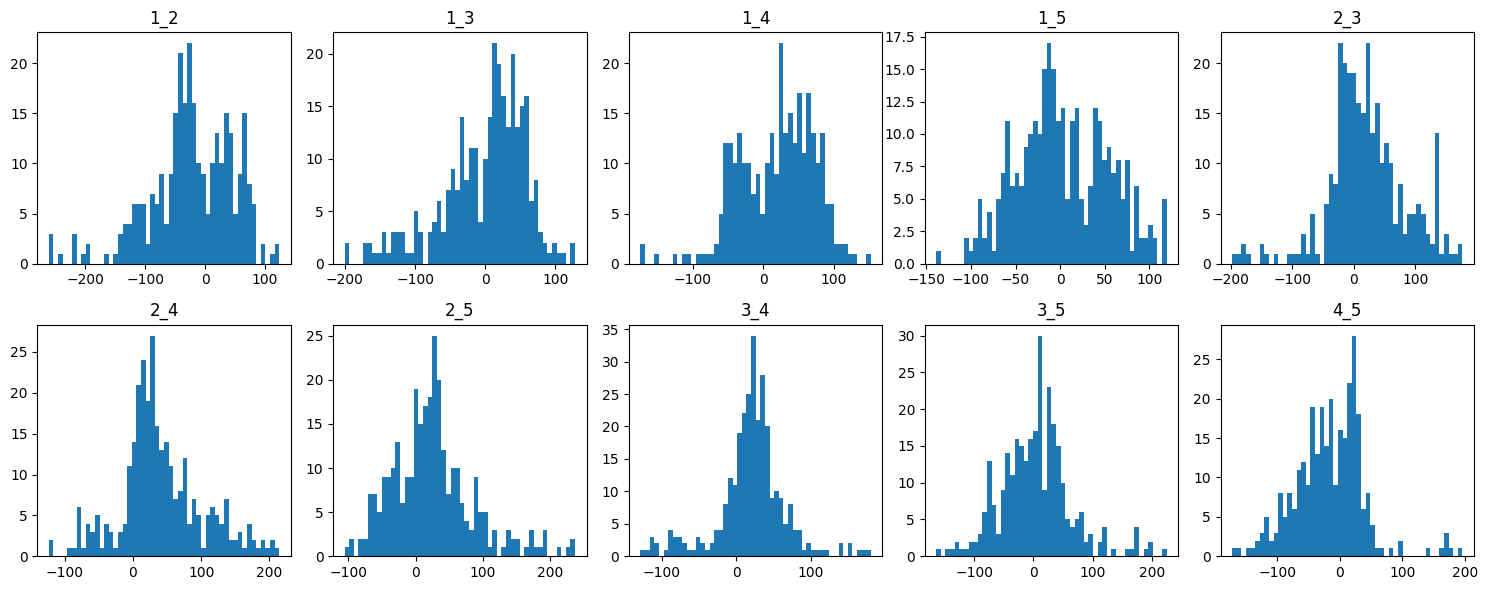

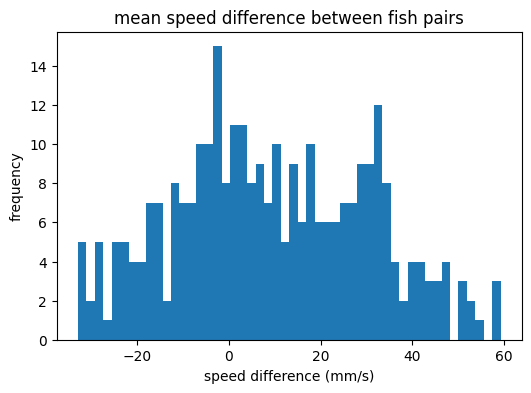

count    301.000000
mean       9.403312
std       21.288257
min      -32.966518
25%       -5.432083
50%        7.513235
75%       26.730742
max       59.368628
dtype: float64


In [21]:
# how different each pair of fish's speed is
speed = pd.DataFrame(index=example_data.index)
for i in range(1, n + 1):
    dx = np.gradient(example_data[f'X{i}'])
    dy = np.gradient(example_data[f'Y{i}'])
    speed[f'{i}'] = np.hypot(dx, dy) * 50

speed_diff = pd.DataFrame(index=example_data.index)
for i in range(1, n + 1):
    for j in range(i +1, n + 1):
        speed_diff[f'{i}_{j}'] = speed[f'{i}'] -speed[f'{j}']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i, col in enumerate(speed_diff.columns):
    axes[i].hist(speed_diff[col], bins=50)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(speed_diff.mean(axis=1), bins=50)
plt.xlabel('speed difference (mm/s)')
plt.ylabel('frequency')
plt.title('Mean speed difference between fish pairs')
plt.show()
print(speed_diff.mean(axis=1).describe())

## Velocity difference - combination of both

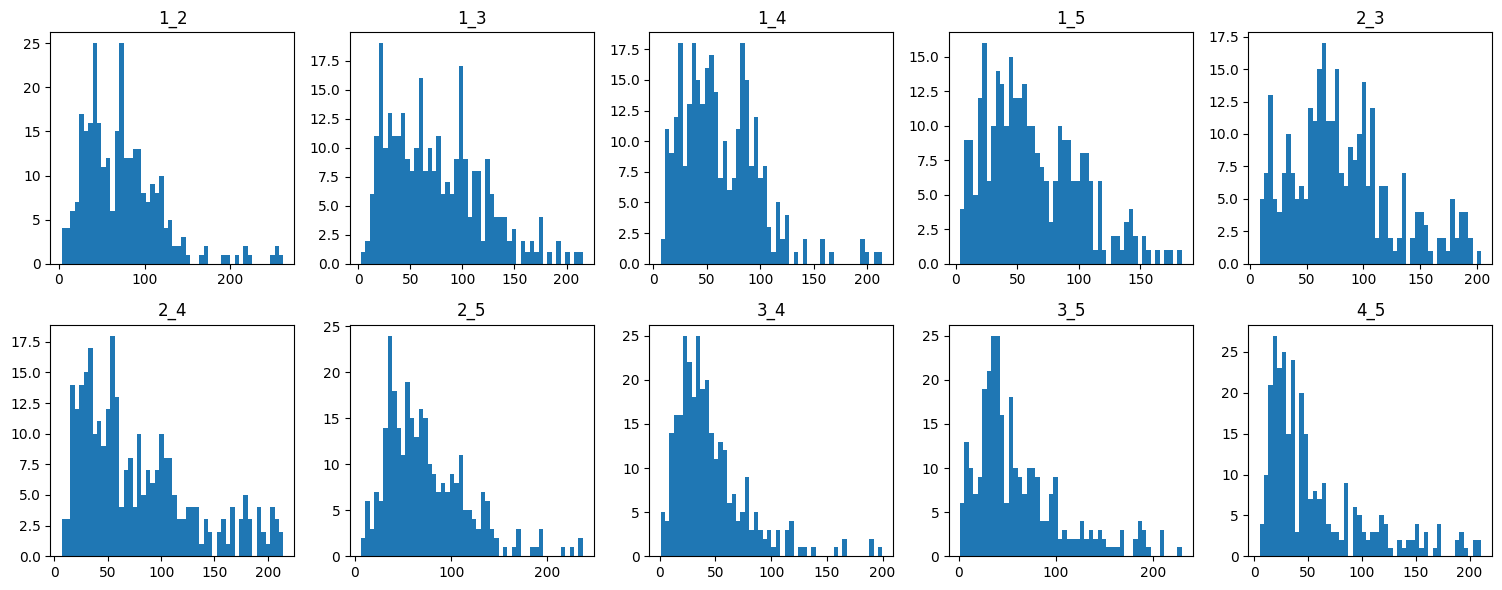

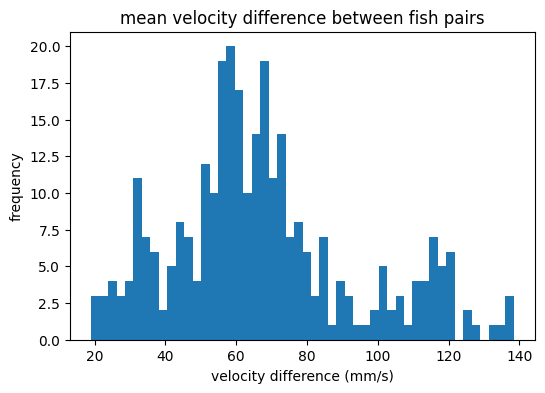

count    301.000000
mean      67.298675
std       26.096974
min       19.003138
25%       51.399759
50%       63.164466
75%       77.638129
max      138.427541
dtype: float64


In [23]:
# fish matching velocity means matching both speed and direction
vel = pd.DataFrame(index=example_data.index)
for i in range(1, n + 1):
    vel[f'VX{i}'] = speed[f'{i}'] * np.cos(example_data[f'H{i}'])
    vel[f'VY{i}'] = speed[f'{i}'] * np.sin(example_data[f'H{i}'])

vel_diff = pd.DataFrame(index=example_data.index)
for i in range(1, n + 1):
    for j in range(i + 1, n + 1):
        dvx = vel[f'VX{i}'] - vel[f'VX{j}']
        dvy = vel[f'VY{i}'] - vel[f'VY{j}']
        vel_diff[f'{i}_{j}'] = np.hypot(dvx, dvy)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i, col in enumerate(vel_diff.columns):
    axes[i].hist(vel_diff[col], bins=50)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(vel_diff.mean(axis=1), bins=50)
plt.xlabel('velocity difference (mm/s)')
plt.ylabel('frequency')
plt.title('mean velocity difference between fish pairs')
plt.show()
print(vel_diff.mean(axis=1).describe())

### Video example Thomas's code

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.ffmpeg_path'] = '/usr/local/bin/ffmpeg'

# Assuming 'example_data' (positions) and 'separations' (distances) 
# are already in your notebook's memory from your previous cells.

example_data = example_data.loc[10200:10500]
vel_diff = vel_diff.loc[10200:10500]

# 1. Setup the Figure and Axes (1 row, 2 columns)
fig, (ax_traj, ax_bar) = plt.subplots(1, 2, figsize=(16, 6))

# --- Setup Scatter Plot (Fish Movement) ---
# Extract coordinate column names dynamically for n=5
x_cols = [f"X{i}" for i in range(1, 6)]
y_cols = [f"Y{i}" for i in range(1, 6)]

# Find the global min and max for consistent axis limits
x_min, x_max = example_data[x_cols].min().min(), example_data[x_cols].max().max()
y_min, y_max = example_data[y_cols].min().min(), example_data[y_cols].max().max()

ax_traj.set_xlim(x_min - 10, x_max + 10) # Padding so fish don't hit the edges
ax_traj.set_ylim(y_min - 10, y_max + 10)
ax_traj.set_title("Fish Trajectories (Overhead View)", fontsize=14)
ax_traj.set_xlabel("X Coordinate")
ax_traj.set_ylabel("Y Coordinate")

# Initialize the scatter plot points
# Initialize with the first frame's data to avoid the size mismatch error
colors = ['red', 'blue', 'green', 'orange', 'purple']
initial_x = example_data[x_cols].iloc[0].values
initial_y = example_data[y_cols].iloc[0].values
scat = ax_traj.scatter(initial_x, initial_y, c=colors, s=150, edgecolors='black', zorder=5)

# --- Setup Bar Chart (Separations) ---
sep_cols = vel_diff.columns
x_pos = np.arange(len(sep_cols))

# Initialize empty bars
bars = ax_bar.bar(x_pos, np.zeros(len(sep_cols)), color='skyblue', edgecolor='black')
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(sep_cols, rotation=45)

# Set static Y-axis limit based on the maximum separation ever achieved
max_sep = vel_diff.max().max()
ax_bar.set_ylim(0, max_sep * 1.1) 
ax_bar.set_title("Pairwise Velocity Differences", fontsize=14)
ax_bar.set_ylabel("Velocity (mm/s)")

# 2. The Update Function (Called once per frame)
def update(frame):
    # Update scatter plot positions
    current_x = example_data[x_cols].iloc[frame].values
    current_y = example_data[y_cols].iloc[frame].values
    scat.set_offsets(np.c_[current_x, current_y])
    
    # Update bar chart heights
    current_seps = vel_diff.iloc[frame].values
    for bar, h in zip(bars, current_seps):
        bar.set_height(h)
        
    # Update title to show time or frame
    fig.suptitle(f"Frame: {frame}", fontsize=16, fontweight='bold')
    
    return scat, *bars

# 3. Compile the Animation
# Note: For testing, you might want to limit frames (e.g., frames=500) rather than len(example_data)
total_frames = len(example_data)
ani = animation.FuncAnimation(fig, update, frames=total_frames, interval=50, blit=False)

plt.close(fig) # Prevents the static empty plot from showing up in Jupyter

# 4. Display or Export
# To view directly inside the Jupyter Notebook:
# display(HTML(ani.to_jshtml()))

# To save as an MP4 for your video presentation (Requires FFmpeg installed):
ani.save("fish_turn_event_velocity.mp4", writer='ffmpeg', fps=20, dpi=150)

# Finding Coefficents (matching/alignment factor)

In [26]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree


def get_continuous_chunks(df, n_fish):
    # need to remove NaN results and work on them in seperate chunks 
    # because data will jump between the chunks 
    columns = [f'X{i}' for i in range(1, n_fish+1)] + [f'Y{i}' for i in range(1, n_fish+1)] + [f'H{i}' for i in range(1, n_fish+1)]
    
    df = df[columns].copy()
    valid = df.notna().all(axis=1)
    chunk_id = (valid != valid.shift()).cumsum()
    
    chunks = []
    for cid, chunk in df.groupby(chunk_id):
        if chunk.notna().all(axis=None):
            chunk = chunk.reset_index(drop=True)
            chunk['timestep'] = range(len(chunk))
            chunks.append(chunk)
    
    return chunks


def find_velocities(chunk, n_fish, fps):
    #converts chunks into their respected velocities
    chunk = chunk.copy()
    dt = 1.0 / fps
    
    for i in range(1, n_fish+1):
        dx = chunk[f'X{i}'].diff()
        dy = chunk[f'Y{i}'].diff()
        speed = np.sqrt(dx**2 + dy**2) /dt
        chunk[f'VX{i}'] = speed * np.cos(chunk[f'H{i}'])
        chunk[f'VY{i}'] = speed * np.sin(chunk[f'H{i}'])
    
    return chunk.dropna().reset_index(drop=True)


def find_all_neighbours(chunk, radius, n_fish):
    # Finds neighbours within a given radius that the fish 
    # would align with, uses cKDtree instead of brute force
    # for effieciency
    neighbours = {(t, i): [] for t in range(len(chunk)) for i in range(1, n_fish+1)}
    
    positions = np.stack([
        chunk[[f'X{i}' for i in range(1, n_fish+1)]].values,
        chunk[[f'Y{i}' for i in range(1, n_fish+1)]].values],axis=2)
    
    for t in range(len(chunk)):
        for a, b in cKDTree(positions[t]).query_pairs(radius):
            neighbours[(t, a+1)].append(b+1)
            neighbours[(t, b+1)].append(a+1)
    
    return neighbours


def compute_matching_factor(chunks, n_fish, radius, min_chunk_length=50):
    #Min Chunk kept at 50 which is only 1 second so keeps nearly all of workable/reliable data
    numerator=0
    denominator=0
    
    for chunk in chunks:
        if len(chunk) < min_chunk_length:
            continue
        
        VX = chunk[[f'VX{i}' for i in range(1, n_fish+1)]].values
        VY = chunk[[f'VY{i}' for i in range(1, n_fish+1)]].values
        all_neighbours = find_all_neighbours(chunk, radius, n_fish)
        
        for t in range(len(chunk) - 1):
            for fish_id in range(1, n_fish+1):
                fi = fish_id - 1
                
                #find neighboring boids within visible range
                neighbours = all_neighbours[(t, fish_id)]
                if len(neighbours) == 0:
                    continue

                #works out the average velocity of all neighbours
                #vel_avg = vel_avg /neighboring_boids

                nidx = [j-1 for j in neighbours]
                xvel_avg = np.mean(VX[t, nidx])
                yvel_avg = np.mean(VY[t, nidx])
                
                #how different the fishes velocity was from its neighbours (required change)
                dvx = xvel_avg - VX[t, fi]
                dvy = yvel_avg - VY[t, fi]
                
                # the actual change of velocity 
                actual_dvx = VX[t+1, fi] - VX[t, fi]
                actual_dvy = VY[t+1, fi] - VY[t, fi]
                
                # instead of working out matching factor for each timestep 
                # (mf = actual / required) then working out average more accurate to
                # use sum of least squares mf = sum(actual * required) / sum(required²)
                # as noise in the data was blowing up the average
                numerator   += actual_dvx * dvx + actual_dvy * dvy
                denominator += dvx ** 2 + dvy ** 2
    return numerator/ denominator


def process_experiments(folder, n_fish, fps, radius):
    files = sorted(glob.glob(f'{folder}/*.csv'))
    print(f'found {len(files)} files in {folder}')
    
    #group chunks by experiment
    exp_chunks = {}
    for f in files:
        df = pd.read_csv(f)
        if not os.path.basename(f).startswith('exp'): # for test file
            continue
        
        exp_id = os.path.basename(f).replace('.csv', '')
        exp_chunks[exp_id] = []
        for chunk in get_continuous_chunks(df, n_fish):
            chunk = find_velocities(chunk, n_fish,fps)
            chunk['exp_id'] = exp_id
            exp_chunks[exp_id].append(chunk)
    
    # compute matching factor per experiment and print as we go
    mf_per_exp = {}
    for exp_id, chunks in exp_chunks.items():
        mf = compute_matching_factor(chunks, n_fish, radius)
        mf_per_exp[exp_id] = mf
        print(f'{exp_id}: mf = {mf:.4f}')
    
    exp_means = pd.Series(mf_per_exp)
    mean_mf = exp_means.mean()
    
    print(f'\nmean matching factor = {mean_mf:.4f} ± {exp_means.std():.4f}')
    return exp_means, mean_mf


# run for both group sizes
exp_means_2, mf_2fish = process_experiments(folder='../data/2', n_fish=2, fps=50, radius=100)
exp_means_5, mf_5fish = process_experiments(folder='../data/5', n_fish=5, fps=50, radius=100)




found 10 files in ../data/2
exp02H20141127_14h13: mf = 0.1494
exp02H20141127_16h29: mf = 0.1673
exp02H20141128_16h06: mf = 0.1581
exp02H20141204_16h01: mf = 0.1197
exp02H20141204_17h28: mf = 0.1577
exp02H20141205_16h11: mf = 0.1614
exp02H20141205_17h37: mf = 0.1367
exp02H20141211_11h11: mf = 0.1008
exp02H20141212_15h45: mf = 0.1425
exp02H20141212_17h12: mf = 0.0742

mean matching factor = 0.1368 ± 0.0300
found 11 files in ../data/5
exp05H20140926_10h50: mf = 0.1719
exp05H20141001_10h05: mf = 0.1831
exp05H20141003_15h00: mf = 0.2336
exp05H20141008_15h30: mf = 0.2157
exp05H20141010_10h38: mf = 0.2770
exp05H20141015_12h50: mf = 0.2499
exp05H20141022_11h45: mf = 0.1824
exp05H20141023_16h20: mf = 0.2648
exp05H20141029_14h20: mf = 0.2547
exp05H20141030_11h15: mf = 0.2198

mean matching factor = 0.2253 ± 0.0371


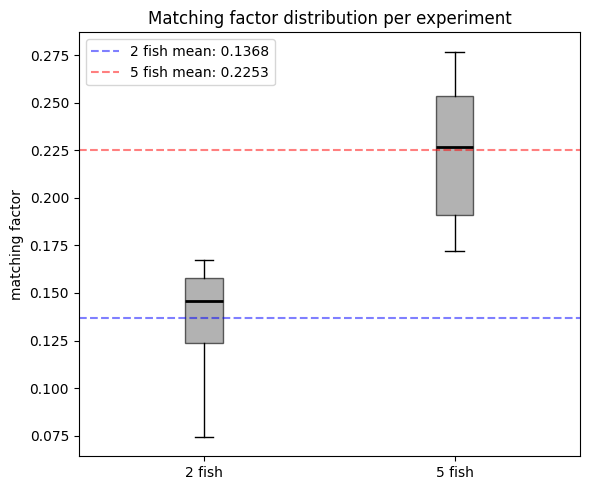

In [23]:
#plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(
    [exp_means_2, exp_means_5],
    tick_labels=['2 fish', '5 fish'],
    patch_artist=True,
    boxprops = dict(facecolor='grey', alpha=0.6),
    medianprops = dict(color='black', linewidth=2)
)
ax.axhline(mf_2fish, color='blue', linestyle='--', alpha=0.5, label=f'2 fish mean: {mf_2fish:.4f}')
ax.axhline(mf_5fish, color='red',linestyle='--', alpha=0.5, label=f'5 fish mean: {mf_5fish:.4f}')
ax.set_ylabel('matching factor')
ax.set_title('Matching factor distribution per experiment')
ax.legend()
plt.tight_layout()
plt.savefig('matching_factor_comparison.png', dpi=150)
plt.show()